In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd
import mysql.connector
# from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.frequent_patterns import fpgrowth, association_rules
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

# Database Connection
db_config = {"host": "localhost", "user": "root", "password": "", "database": "electrical_pos"}
conn = mysql.connector.connect(**db_config)

D:\Python\electronic_pos_market_basket\venv\lib\site-packages\matplotlib\_fontconfig_pattern.py:64: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))
D:\Python\electronic_pos_market_basket\venv\lib\site-packages\matplotlib\_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
D:\Python\electronic_pos_market_basket\venv\lib\site-packages\matplotlib\_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
D:\Python\electronic_pos_market_basket\venv\lib\site-packages\matplotlib\_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
D:\Python\electronic_pos_market_basket\venv\lib\site-packages\matplotlib\_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 're

In [4]:
# query_basket = """
#     SELECT ti.trans_id, p.product_name 
#     FROM transaction_items ti 
#     JOIN products p ON ti.product_id = p.product_id
#     JOIN transactions t ON ti.trans_id = t.trans_id
#     WHERE t.status = 'Completed'
#       AND t.trans_date >= DATE_SUB(CURDATE(), INTERVAL 6 MONTH)
# """ 
# df = pd.read_sql(query_basket, conn)

In [5]:
# Database ထဲက အချက်အလက်အစိမ်းတွေကိုပဲ ဆွဲထုတ်မယ်
query_raw = """
    SELECT 
        t.trans_id, 
        p.product_name,
        ti.quantity,
        p.price,
        t.trans_date,
        t.status
    FROM transactions t
    JOIN transaction_items ti ON t.trans_id = ti.trans_id
    JOIN products p ON ti.product_id = p.product_id
    WHERE t.status = 'Completed'
      AND t.trans_date >= DATE_SUB(CURDATE(), INTERVAL 6 MONTH)
"""
df_raw = pd.read_sql(query_raw, conn)

In [6]:
df_raw

,trans_id,product_name,quantity,price,trans_date,status
0,1,Gang Box,1,1200.0,2025-10-14 20:22:45,Completed
1,1,Wire 1.5mm,1,45000.0,2025-10-14 20:22:45,Completed
2,1,Wall Switch,1,2500.0,2025-10-14 20:22:45,Completed
3,1,Electric Tape,1,1000.0,2025-10-14 20:22:45,Completed
4,2,Wire 1.5mm,1,45000.0,2025-08-14 19:44:43,Completed
...,...,...,...,...,...,...
15245,5003,Deep Cycle Battery,3,450000.0,2025-12-22 19:21:54,Completed
15246,5003,Solar Controller,1,35000.0,2025-12-22 19:21:54,Completed
15247,5004,Electric Kettle,2,28000.0,2025-10-20 19:52:41,Completed
15248,5005,Inverter 1000W,1,250000.0,2026-02-08 20:40:44,Completed


In [7]:
df_raw.count()

trans_id        15250
product_name    15250
quantity        15250
price           15250
trans_date      15250
status          15250
dtype: int64

In [8]:
df_raw.describe()

,trans_id,quantity,price,trans_date
count,15250.000000,15250.000000,15250.000000,15250
mean,2515.840590,1.592197,100053.036066,2025-11-10 12:45:09.025573632
min,1.000000,1.000000,1000.000000,2025-08-12 21:46:05
25%,1266.000000,1.000000,4500.000000,2025-09-25 09:42:04.500000
50%,2522.000000,1.000000,35000.000000,2025-11-10 00:15:03
75%,3770.000000,2.000000,125000.000000,2025-12-25 11:32:00.249999872
max,5005.000000,4.000000,480000.000000,2026-02-09 19:05:20
std,1443.498303,0.795953,142181.179164,NaN


In [9]:
# --- ၃.၂ Data Cleaning & Preprocessing (Extended) ---

# ၁။ Check for Missing/Null Values
null_count = df_raw.isnull().sum().sum()
print(f"Initial Null values found: {null_count}")

Initial Null values found: 0


In [10]:

# တကယ်လို့ Null ရှိရင် drop လုပ်မယ် (သို့မဟုတ် zero နဲ့ fill လုပ်မယ်)
df_raw = df_raw.dropna() 

In [11]:

# ၂။ Check for Duplicates
duplicate_rows = df_raw.duplicated().sum()
print(f"Duplicate rows found: {duplicate_rows}")


Duplicate rows found: 1


In [12]:
df_raw = df_raw.drop_duplicates()

In [13]:
duplicate_rows = df_raw.duplicated().sum()
print(f"Duplicate rows found: {duplicate_rows}")

Duplicate rows found: 0


In [14]:

# ၃။ Data Integrity Check (Negative values တွေ မပါစေရ)
# အရေအတွက် သို့မဟုတ် ဈေးနှုန်း က ၀ ထက်နည်းနေတာတွေ ရှိရင် ဖယ်ထုတ်မယ်
df_raw = df_raw[(df_raw['quantity'] > 0) & (df_raw['price'] > 0)]

In [15]:
# Outlier
# ၄။ Handling Outliers in Price/Quantity (Z-Score method)
# ပုံမှန်မဟုတ်ဘဲ အရမ်းများနေတဲ့ ဈေးနှုန်း ဒါမှမဟုတ် အရေအတွက်တွေကို ရှာမယ်
from scipy import stats
import numpy as np

#adding new features
# တန်ဖိုးတစ်ခုချင်းစီအတွက် Total Revenue တွက်ထားမယ် (Forecasting/Quadrant အတွက် သုံးလို့ရအောင်)
df_raw['total_price'] = df_raw['quantity'] * df_raw['price']

original_len = len(df_raw)

# Total Price ပေါ်မှာ မူတည်ပြီး Outlier ရှာခြင်း
z_scores = np.abs(stats.zscore(df_raw['total_price']))
# Z-score > 3 ဆိုရင် extreme outlier လို့ သတ်မှတ်ပြီး ဖယ်ထုတ်မယ် 
df_raw = df_raw[z_scores < 3]

final_len = len(df_raw)
print(f"Removed {original_len - final_len} abnormal transactions as noise.")
print(f"Cleaned Data shape: {df_raw.shape}")

Removed 319 abnormal transactions as noise.
Cleaned Data shape: (14930, 7)


In [16]:
df_raw.count()

trans_id        14930
product_name    14930
quantity        14930
price           14930
trans_date      14930
status          14930
total_price     14930
dtype: int64

In [17]:
# df_raw['product_name'].head(5)

In [18]:


# ၅။ String Normalization 
# df_raw['product_name'] = df_raw['product_name'].str.strip().str.title() # ရှေ့နောက်ဖြတ်ပြီး စာလုံးအကြီးအသေး ညီအောင်လုပ်မယ်



In [19]:
# df_raw['product_name'].head(5)

In [20]:
# ၁။ Pivot Table လုပ်ခြင်း (Transaction အလိုက် Column များခွဲခြင်း)
basket = (df_raw.groupby(['trans_id', 'product_name'])['product_name']
          .count().unstack()
          .reset_index().fillna(0)
          .set_index('trans_id'))

# ၂။ One-Hot Encoding (Binary Matrix 0/1 ပြောင်းခြင်း)
# ဒါက Preprocessing ရဲ့ အရေးကြီးဆုံး အစိတ်အပိုင်းပါ
basket_sets = basket.applymap(lambda x: 1 if x >= 1 else 0)

print("Preprocessing ပြီးစီးထားသော Basket Data:")
print(basket_sets.head())

Preprocessing ပြီးစီးထားသော Basket Data:
product_name   Gang Box  Battery Charger  Blender  Ceiling Light  \
trans_id                                                           
1                     1                0        0              0   
2                     0                0        0              0   
3                     0                0        0              0   
4                     1                0        0              0   
5                     0                0        0              0   

product_name  Circuit Breaker  DC Breaker  Deep Cycle Battery  \
trans_id                                                        
1                           0           0                   0   
2                           0           0                   0   
3                           0           0                   0   
4                           0           0                   0   
5                           0           0                   1   

product_name  Digital Mult

In [21]:
# --- ၅။ FP-Growth Mining ---
frequent_itemsets = fpgrowth(basket_sets, min_support=0.01, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# Database နဲ့ Visualization အတွက် String အဖြစ် ပြောင်းလဲခြင်း (Multi-item support ပါဝင်သည်)
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)).strip())
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(list(x)).strip())

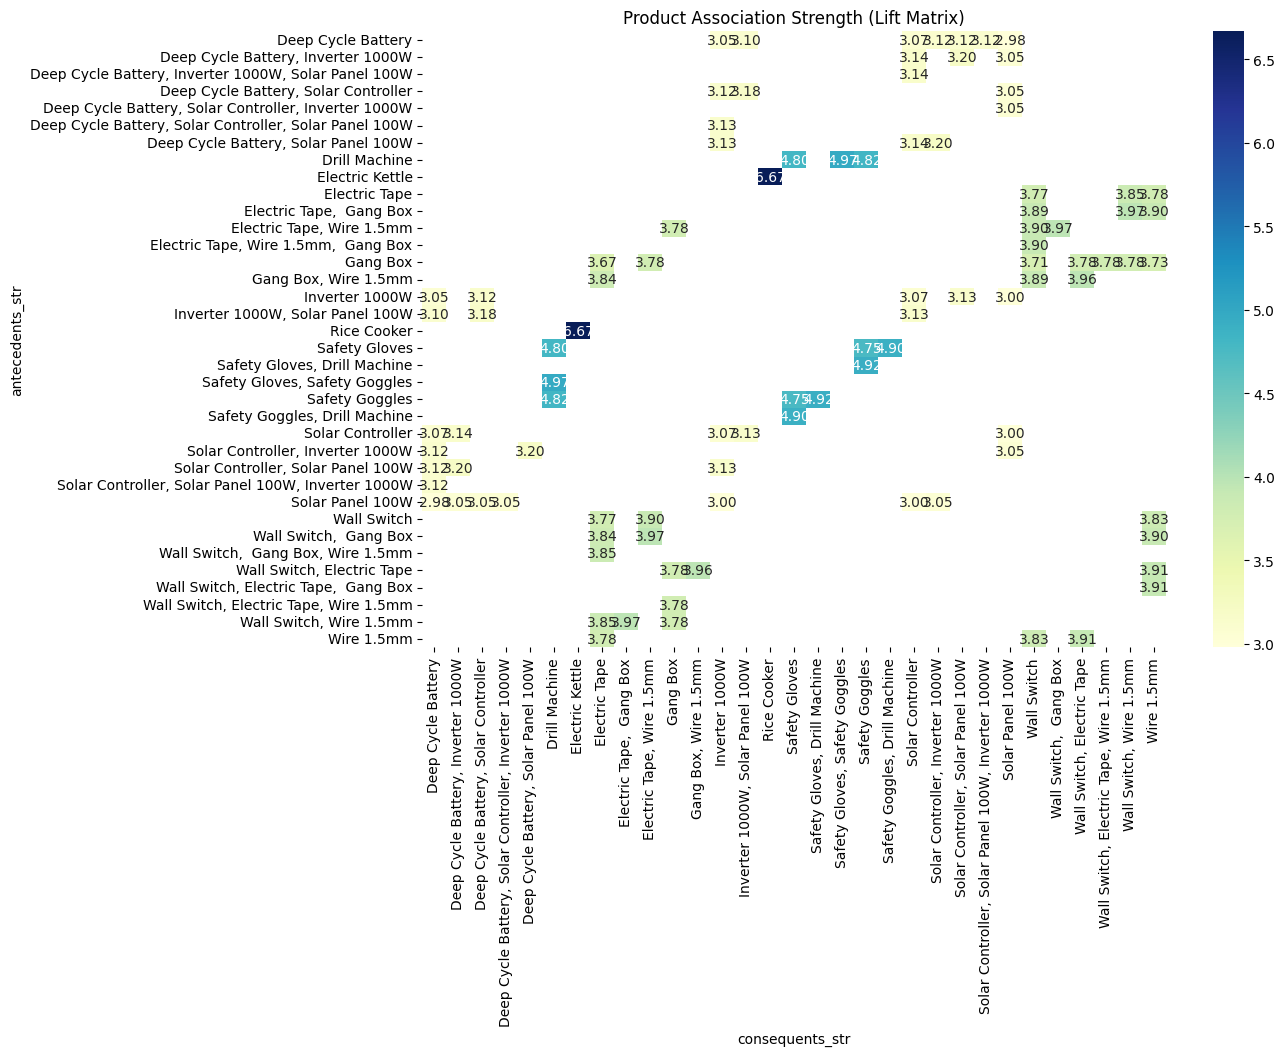

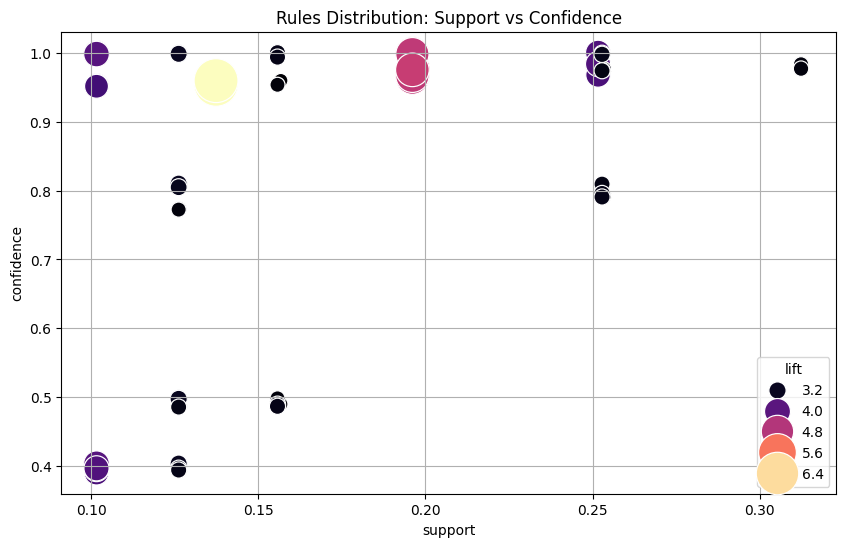

In [22]:
# --- ၆။ Visualization (Heatmap & Scatter) ---

# Heatmap ဆွဲဖို့အတွက် String Column ကို သုံးပါ (Frozenset သုံးရင် Error တက်နိုင်လို့ပါ)
filtered_rules = rules[rules['confidence'] > 0.4] # Confidence threshold 
pivot = filtered_rules.pivot_table(index='antecedents_str', columns='consequents_str', values='lift', aggfunc='max')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title('Product Association Strength (Lift Matrix)')
plt.show()

# Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x="support", y="confidence", size="lift", hue="lift", 
                data=rules, palette="magma", sizes=(100, 1000))
plt.title('Rules Distribution: Support vs Confidence')
plt.grid(True)
plt.show()

In [23]:
# ၁။ Duplicate ဘယ်နှစ်ခုရှိလဲ အရင်ရှာမယ်
duplicate_count = rules.duplicated(subset=['antecedents_str', 'consequents_str']).sum()

print(f"ရှာဖွေတွေ့ရှိသည့် Duplicate Rules အရေအတွက်: {duplicate_count}")

# ၂။ Duplicate Rules တွေကို ကြည့်ချင်ရင် (ပထမ ၅ ခုကို နမူနာထုတ်ပြမယ်)
if duplicate_count > 0:
    print("\nနမူနာ Duplicate ဖြစ်နေသော Rules များ:")
    print(rules[rules.duplicated(subset=['antecedents_str', 'consequents_str'], keep=False)].sort_values('confidence', ascending=False).head())

# ၃။ အခုမှ Clean လုပ်မယ် (Confidence အမြင့်ဆုံးကို ချန်ထားမယ်)
rules_cleaned = rules.sort_values('confidence', ascending=False).drop_duplicates(subset=['antecedents_str', 'consequents_str'])

print(f"\nCleaning လုပ်ပြီးနောက် ကျန်ရှိသည့် Rules အရေအတွက်: {len(rules_cleaned)}")

ရှာဖွေတွေ့ရှိသည့် Duplicate Rules အရေအတွက်: 0

Cleaning လုပ်ပြီးနောက် ကျန်ရှိသည့် Rules အရေအတွက်: 114


In [24]:
# --- ၇။ Database ထဲသို့ Rules များ သိမ်းဆည်းခြင်း ---


cursor = conn.cursor()
cursor.execute("TRUNCATE TABLE recommendation_rules")

for idx, row in rules_cleaned.iterrows():
    cursor.execute("""
        INSERT INTO recommendation_rules (antecedent, consequent, confidence, lift)
        VALUES (%s, %s, %s, %s)
    """, (row['antecedents_str'], row['consequents_str'], row['confidence'], row['lift']))

conn.commit()
print(f"✅ Success! {len(rules_cleaned)} rules saved to database.\n")

# --- Rules များကို ရှင်းရှင်းလင်းလင်း Visualize လုပ်ပြီး Print ထုတ်ရန် ---
print("-" * 80)
print(f"{'IF (Bought These)':<40} | {'THEN (Recommended)':<20} | {'CONFIDENCE'}")
print("-" * 80)

#  rules ကို စာသားနဲ့ ဖတ်လို့ကောင်းအောင် ပြမယ်
for idx, row in rules_cleaned.iterrows():
    # Antecedents က ပစ္စည်းတစ်ခုထက်ပိုရင် (A + B) ပုံစံပြမယ်
    if ", " in row['antecedents_str']:
        if_part = f"({row['antecedents_str']})"
    else:
        if_part = row['antecedents_str']
        
    then_part = row['consequents_str']
    conf_percent = f"{row['confidence']*100:.1f}%"
    
    print(f"{if_part:<40} | {then_part:<20} | {conf_percent}")

print("-" * 80)

✅ Success! 114 rules saved to database.

--------------------------------------------------------------------------------
IF (Bought These)                        | THEN (Recommended)   | CONFIDENCE
--------------------------------------------------------------------------------
(Wall Switch, Wire 1.5mm)                | Electric Tape        | 100.0%
(Electric Tape, Wire 1.5mm)              | Wall Switch          | 100.0%
(Wall Switch,  Gang Box, Wire 1.5mm)     | Electric Tape        | 100.0%
(Wall Switch, Electric Tape,  Gang Box)  | Wire 1.5mm           | 100.0%
(Electric Tape, Wire 1.5mm,  Gang Box)   | Wall Switch          | 100.0%
(Deep Cycle Battery, Solar Panel 100W)   | Inverter 1000W       | 100.0%
(Solar Controller, Solar Panel 100W)     | Inverter 1000W       | 100.0%
(Deep Cycle Battery, Solar Controller, Solar Panel 100W) | Inverter 1000W       | 100.0%
(Deep Cycle Battery, Solar Controller)   | Inverter 1000W       | 99.9%
(Wall Switch, Electric Tape)             | Wire 

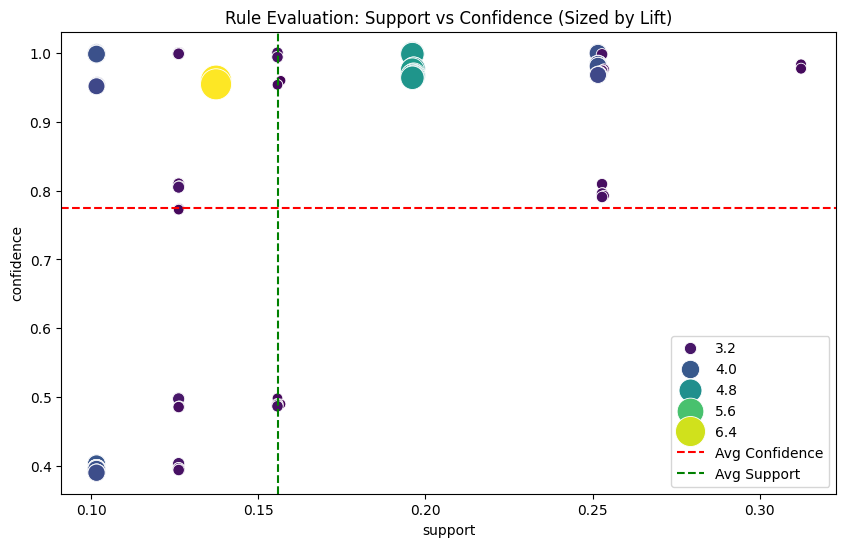

In [25]:
# Rule Quality Evaluation using Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x="support", y="confidence", size="lift", hue="lift", 
                data=rules_cleaned, palette="viridis", sizes=(50, 500))

# Mean lines for average quality identification
plt.axhline(y=rules_cleaned['confidence'].mean(), color='r', linestyle='--', label='Avg Confidence')
plt.axvline(x=rules_cleaned['support'].mean(), color='g', linestyle='--', label='Avg Support')

plt.title('Rule Evaluation: Support vs Confidence (Sized by Lift)')
plt.legend()
plt.show()

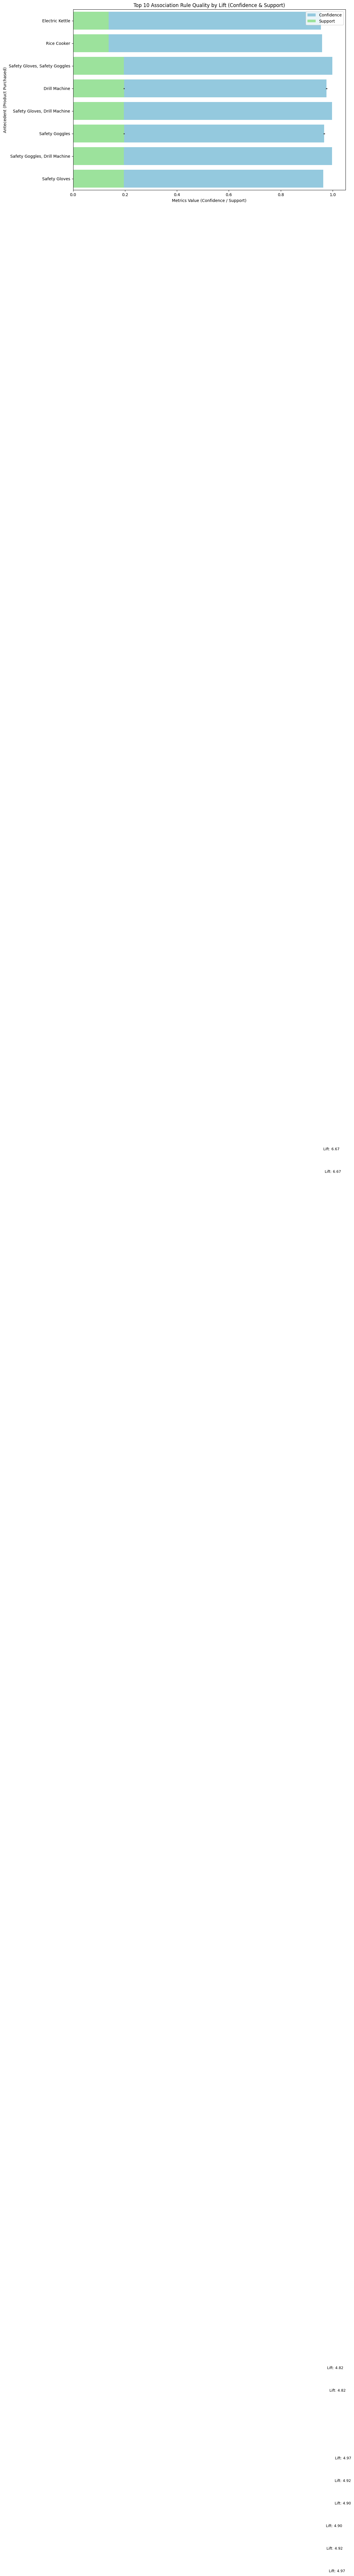


--- Top 10 Rules: Consequents ---
Rule 51: Electric Kettle -> Rice Cooker
Rule 52: Rice Cooker -> Electric Kettle
Rule 109: Safety Gloves, Safety Goggles -> Drill Machine
Rule 114: Drill Machine -> Safety Gloves, Safety Goggles
Rule 110: Safety Gloves, Drill Machine -> Safety Goggles
Rule 113: Safety Goggles -> Safety Gloves, Drill Machine
Rule 111: Safety Goggles, Drill Machine -> Safety Gloves
Rule 112: Safety Gloves -> Safety Goggles, Drill Machine
Rule 106: Drill Machine -> Safety Goggles
Rule 105: Safety Goggles -> Drill Machine


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top N rules ကိုပဲ ရွေးထုတ်ပြီးပြရင် ပိုရှင်းတယ် (ဥပမာ: Lift အမြင့်ဆုံး Top 10)
# ဒါမှမဟုတ် Confidence အမြင့်ဆုံး Top 10 လည်း ရပါတယ်
top_rules = rules_cleaned.sort_values('lift', ascending=False).head(10)

# Plotting the Combined Bar Chart
plt.figure(figsize=(12, 8))

# Confidence Bar
sns.barplot(x="confidence", y="antecedents_str", data=top_rules, color='skyblue', label='Confidence')
# Support Bar (Confidence ရဲ့ အောက်မှာ ကပ်ပြမယ်)
sns.barplot(x="support", y="antecedents_str", data=top_rules, color='lightgreen', label='Support')
# Lift Value တွေကို Text အနေနဲ့ Bar Chart ပေါ်မှာ ရေးပြမယ်
for index, row in top_rules.iterrows():
    plt.text(row['confidence'] + 0.01, index, f"Lift: {row['lift']:.2f}", color='black', ha="left", va='center', fontsize=9)

plt.xlabel('Metrics Value (Confidence / Support)')
plt.ylabel('Antecedent (Product Purchased)')
plt.title('Top 10 Association Rule Quality by Lift (Confidence & Support)')
plt.legend()
plt.tight_layout()
plt.show()

# Consequent တွေကိုလည်း သပ်သပ်ဖော်ပြဖို့
print("\n--- Top 10 Rules: Consequents ---")
for index, row in top_rules.iterrows():
    print(f"Rule {index+1}: {row['antecedents_str']} -> {row['consequents_str']}")

In [27]:
# Lift အမြင့်ဆုံး Top 10 rules ကို ဇယားနဲ့ပြမယ်
top_10_rules = rules_cleaned.nlargest(15, 'lift')

# ဖတ်ရလွယ်အောင် column လေးတွေပဲ ရွေးထုတ်မယ်
display_table = top_10_rules[['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']]
display_table.columns = ['If Buy (A)', 'Then Buy (B)', 'Support', 'Confidence', 'Lift Strength']

print("Top 10 Strongest Product Associations:")
print(display_table.to_string(index=False))

Top 10 Strongest Product Associations:
                   If Buy (A)                  Then Buy (B)  Support  Confidence  Lift Strength
                  Rice Cooker               Electric Kettle 0.137318    0.959497       6.667173
              Electric Kettle                   Rice Cooker 0.137318    0.954167       6.667173
Safety Gloves, Safety Goggles                 Drill Machine 0.196082    0.998982       4.968097
                Drill Machine Safety Gloves, Safety Goggles 0.196082    0.975149       4.968097
 Safety Gloves, Drill Machine                Safety Goggles 0.196082    0.997965       4.919035
               Safety Goggles  Safety Gloves, Drill Machine 0.196082    0.966502       4.919035
Safety Goggles, Drill Machine                 Safety Gloves 0.196082    0.997965       4.904539
                Safety Gloves Safety Goggles, Drill Machine 0.196082    0.963654       4.904539
                Drill Machine                Safety Goggles 0.196482    0.977137       4.816372
 

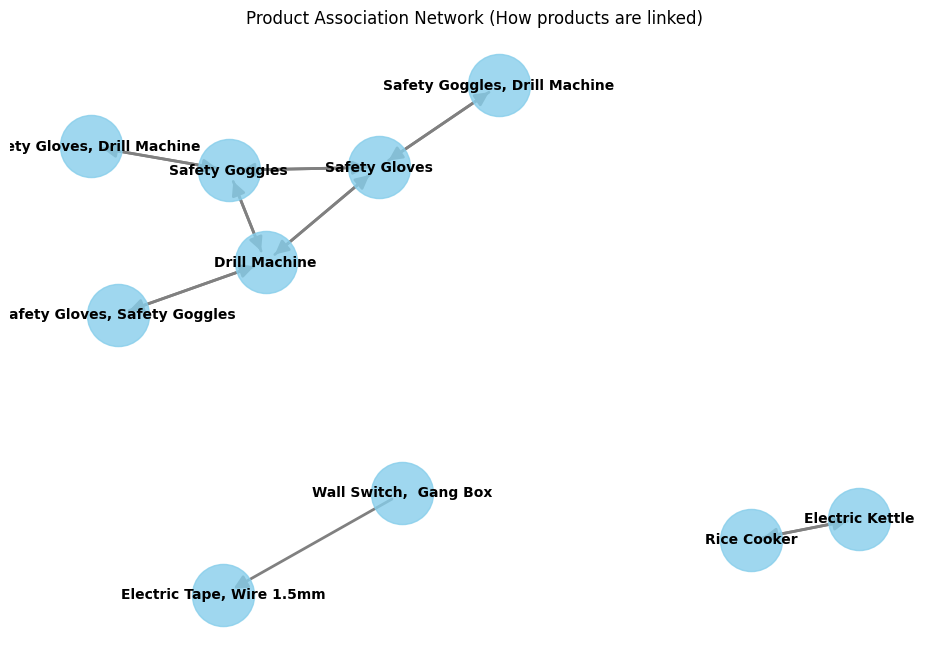

In [28]:
import networkx as nx

# Top 10 rules ကိုပဲ ပုံဖော်မယ်
G = nx.DiGraph()
for _, row in top_10_rules.iterrows():
    G.add_edge(row['antecedents_str'], row['consequents_str'], weight=row['lift'])

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=1.0)

# Nodes နဲ့ Labels ဆွဲမယ်
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color="skyblue", alpha=0.8)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")

# မြှား (Edges) ဆွဲမယ်
nx.draw_networkx_edges(G, pos, width=2, edge_color="gray", arrowsize=20)

plt.title("Product Association Network (How products are linked)")
plt.axis('off')
plt.show()

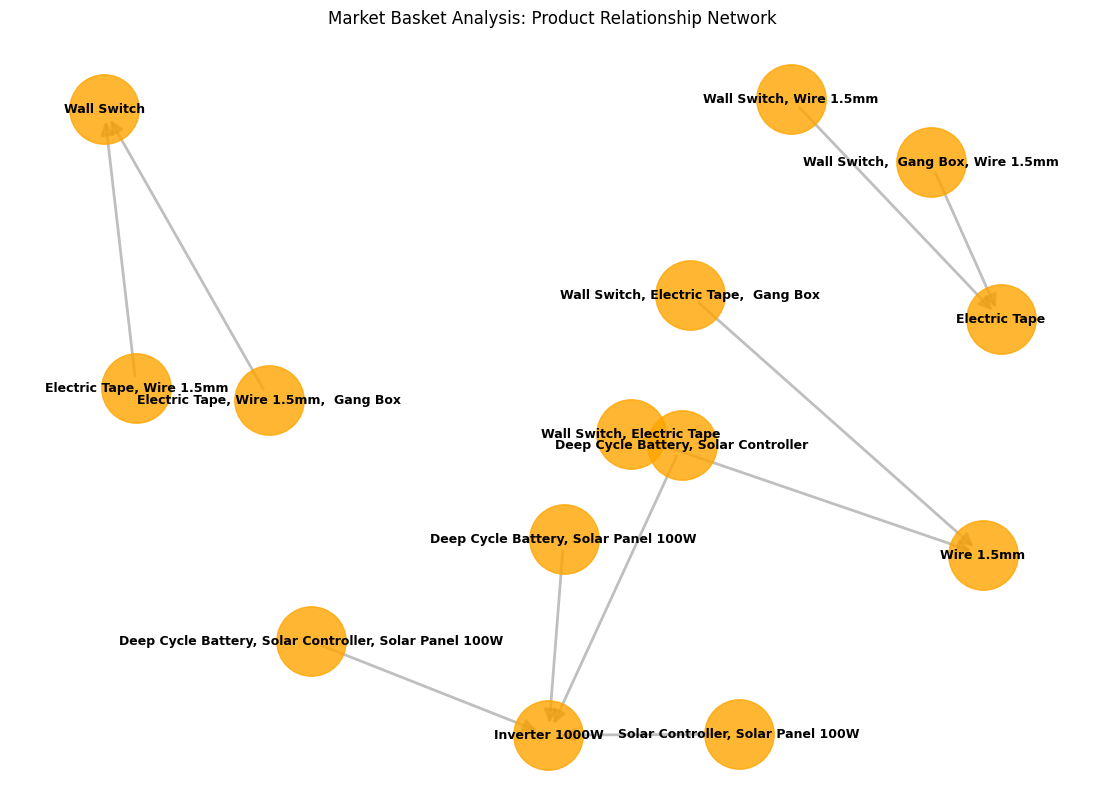

In [29]:
import networkx as nx

# Top 15 rules ကိုပဲ ယူမယ်
top_15 = rules_cleaned.head(10)

plt.figure(figsize=(14, 10))
G = nx.DiGraph()

for idx, row in top_15.iterrows():
    # Antecedent ကနေ Consequent ဆီကို မြှားဆွဲမယ်
    G.add_edge(row['antecedents_str'], row['consequents_str'], weight=row['confidence'])

# နေရာချထားမှုပုံစံ (Spring layout က ကြည့်လို့အကောင်းဆုံးပါ)
pos = nx.spring_layout(G, k=0.8, seed=42)

# Nodes (ပစ္စည်းနာမည်များ) ဆွဲမယ်
nx.draw_networkx_nodes(G, pos, node_size=2500, node_color="orange", alpha=0.8)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold")

# Edges (မြှားများ) ဆွဲမယ်
nx.draw_networkx_edges(G, pos, width=2, edge_color="gray", arrowsize=20, alpha=0.5)

plt.title("Market Basket Analysis: Product Relationship Network")
plt.axis('off')
plt.show()

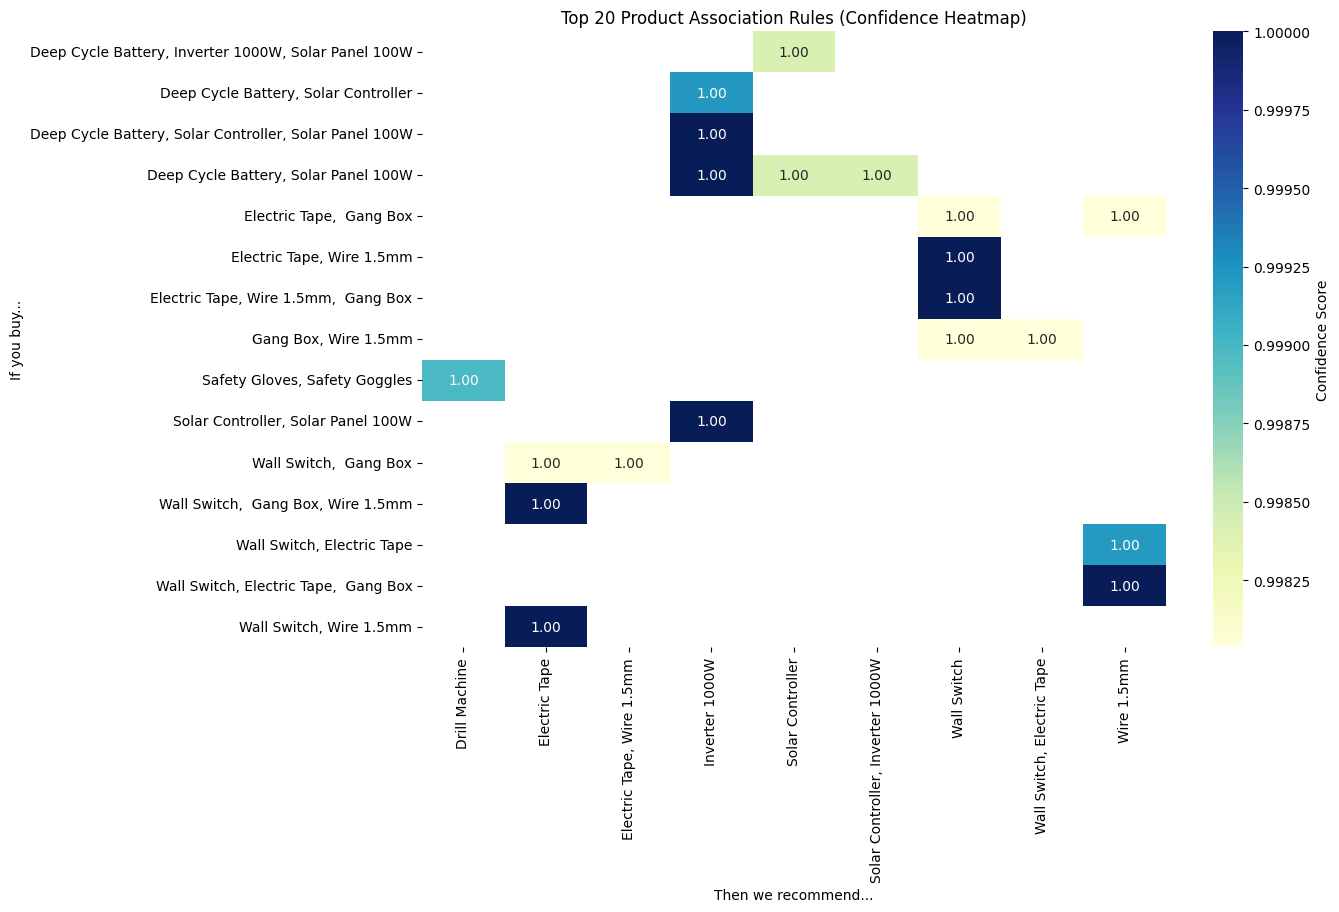

In [30]:
from pandas.plotting import parallel_coordinates

# Confidence 0.3 ထက်များတဲ့ rule တွေကိုပဲ ရွေးထုတ်မယ်
plot_rules = rules_cleaned[rules_cleaned['confidence'] > 0.3].head(20)

# pivot table ပြန်ဆောက်မယ်
pivot = plot_rules.pivot_table(index='antecedents_str', 
                               columns='consequents_str', 
                               values='confidence')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, cmap="YlGnBu", fmt=".2f", cbar_kws={'label': 'Confidence Score'})
plt.title('Top 20 Product Association Rules (Confidence Heatmap)')
plt.ylabel('If you buy...')
plt.xlabel('Then we recommend...')
plt.show()

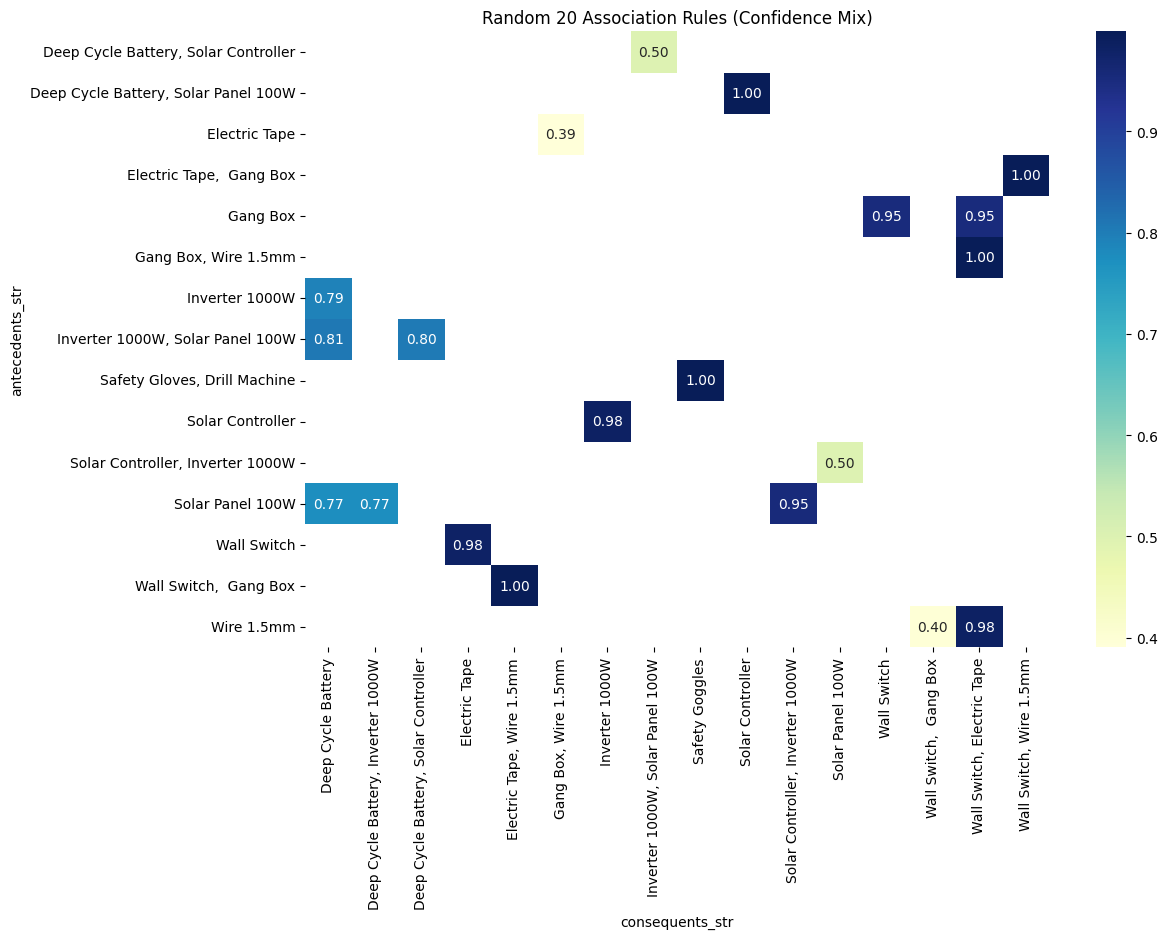

In [31]:
# Confidence 0.3 ထက်များတဲ့ rules တွေထဲကမှ ကျပန်း ၂၀ ခုကို ရွေးမယ်
# (random_state=42 ထည့်ထားရင် run တိုင်း ဒီ ၂၀ ခုပဲ ထွက်နေမှာမို့၊ 
# အမြဲပြောင်းစေချင်ရင် random_state ကို ဖြုတ်ထားလို့ရပါတယ်)
plot_rules = rules_cleaned[rules_cleaned['confidence'] > 0.3].sample(20)

# --- Visualize လုပ်တဲ့အပိုင်း (Heatmap ဖြင့်ပြခြင်း) ---
pivot = plot_rules.pivot_table(index='antecedents_str', 
                               columns='consequents_str', 
                               values='confidence')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title('Random 20 Association Rules (Confidence Mix)')
plt.show()

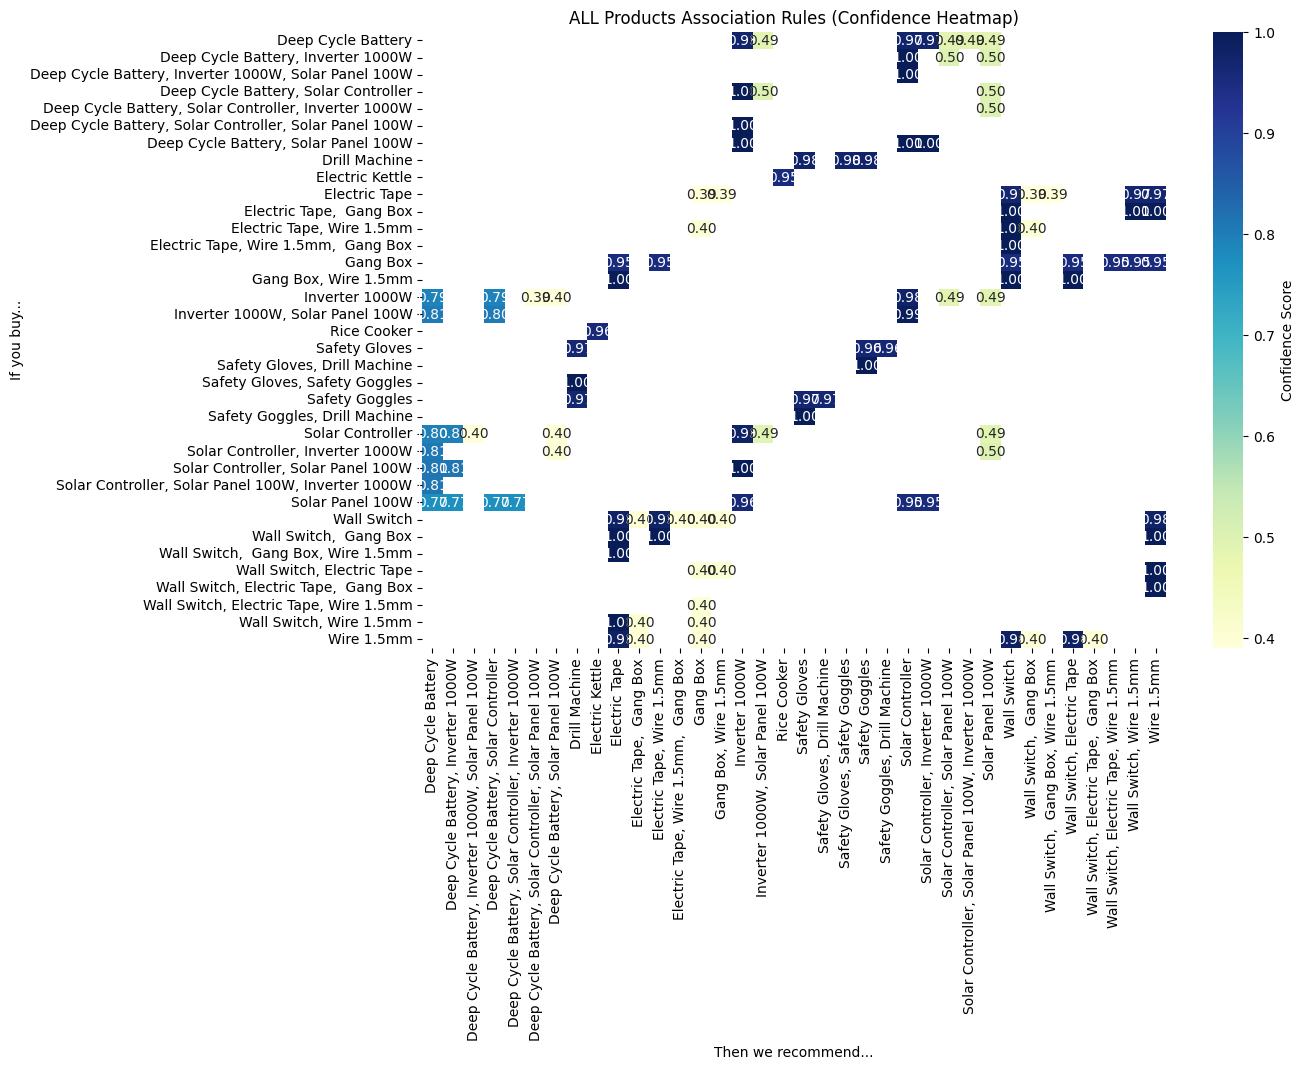

In [32]:
from pandas.plotting import parallel_coordinates

# Confidence 0.3 ထက်များတဲ့ rule တွေကိုပဲ ရွေးထုတ်မယ်
plot_rules = rules_cleaned[rules_cleaned['confidence'] > 0.3]

# pivot table ပြန်ဆောက်မယ်
pivot = plot_rules.pivot_table(index='antecedents_str', 
                               columns='consequents_str', 
                               values='confidence')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, cmap="YlGnBu", fmt=".2f", cbar_kws={'label': 'Confidence Score'})
plt.title('ALL Products Association Rules (Confidence Heatmap)')
plt.ylabel('If you buy...')
plt.xlabel('Then we recommend...')
plt.show()

In [33]:
# Forecast Sale
import numpy as np
query = """
    SELECT DATE_FORMAT(t.trans_date, '%Y-%m') as month, 
           SUM(ti.quantity * p.price) as monthly_revenue
    FROM transactions t
    JOIN transaction_items ti ON t.trans_id = ti.trans_id
    JOIN products p ON ti.product_id = p.product_id
    WHERE t.status = 'completed'
    GROUP BY month ORDER BY month ASC
"""
df = pd.read_sql(query, conn)

# လအလိုက် Index နံပါတ်ပေးမယ် (ဥပမာ 0, 1, 2...)
df['month_index'] = np.arange(len(df))

In [34]:
from sklearn.linear_model import LinearRegression
# X က အချိန် (Month Index)၊ y က ရောင်းရငွေ (Revenue)
X = df[['month_index']]
y = df['monthly_revenue']

model = LinearRegression()
model.fit(X, y)

# နောက်လအတွက် ခန့်မှန်းမယ်
next_month = np.array([[len(df)]])
prediction = model.predict(next_month)

print(f"လာမည့်လအတွက် ခန့်မှန်းခြေရောင်းအား: {prediction[0]:,.0f} MMK")

လာမည့်လအတွက် ခန့်မှန်းခြေရောင်းအား: 283,579,629 MMK


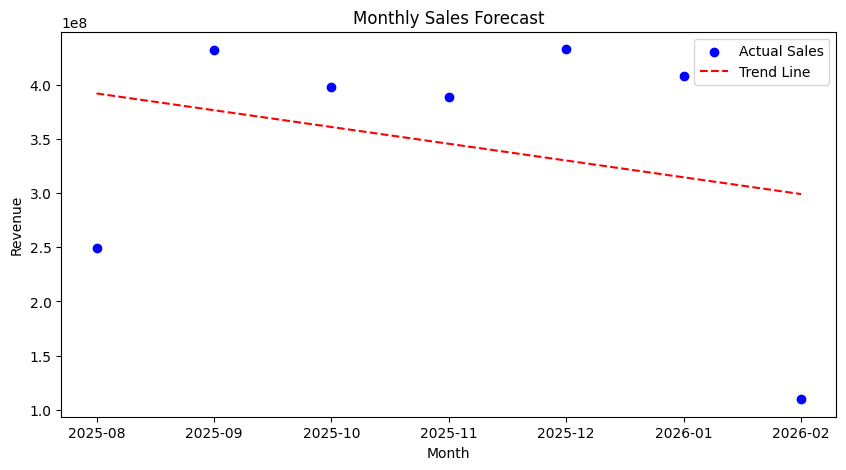

In [35]:
plt.figure(figsize=(10, 5))
plt.scatter(df['month'], df['monthly_revenue'], color='blue', label='Actual Sales')
plt.plot(df['month'], model.predict(X), color='red', linestyle='--', label='Trend Line')
plt.title('Monthly Sales Forecast')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.legend()
plt.show()

In [36]:
# Product Table ထဲက လက်ရှိ Stock တွေကို ဆွဲထုတ်မယ်
query_products = "SELECT product_name, stock_quantity FROM products"
products_df = pd.read_sql(query_products, conn)

In [37]:
# ၁။ နေ့စဉ် အရောင်းနှုန်း (Daily Velocity) တွက်ခြင်း
# လွန်ခဲ့တဲ့ ရက် ၃၀ ဒေတာကို သုံးမယ်
daily_sales = df_raw.groupby('product_name')['quantity'].sum() / 30

# ၂။ လက်ရှိ Stock ဒေတာနဲ့ ချိတ်ဆက်ခြင်း (မင်းရဲ့ products dataframe ရှိရပါမယ်)
# ဒီမှာ ဥပမာအနေနဲ့ products_df လို့ သုံးထားပါတယ်
inventory_df = products_df[['product_name', 'stock_quantity']].copy()
inventory_df['daily_velocity'] = inventory_df['product_name'].map(daily_sales).fillna(0)

# ၃။ ပြတ်လပ်ရန် ကျန်သည့်ရက်ကို တွက်ခြင်း (Estimated Days Left)
inventory_df['days_left'] = inventory_df['stock_quantity'] / inventory_df['daily_velocity']

# ၄။ Mining Logic ပေါင်းထည့်ခြင်း (Association Importance)
# ဘယ်ပစ္စည်းတွေက အခြားပစ္စည်းတွေအတွက် 'တွဲဖက်' (Antecedent) ဖြစ်နေလဲဆိုတာ ရှာမယ်
frequent_antecedents = rules_cleaned['antecedents_str'].unique()
inventory_df['is_key_associator'] = inventory_df['product_name'].apply(lambda x: "Yes" if x in frequent_antecedents else "No")

# ၅။ Alert Filter ထုတ်ခြင်း
# ၇ ရက်အောက်ကျန်တာ (သို့) Stock ၅ ခုအောက်ကျန်တာကို ယူမယ်
alerts = inventory_df[(inventory_df['days_left'] <= 7) | (inventory_df['stock_quantity'] <= 5)]

print("--- Predictive Stock Alerts (Mining Integrated) ---")
print(alerts[['product_name', 'stock_quantity', 'days_left', 'is_key_associator']].sort_values('days_left'))

--- Predictive Stock Alerts (Mining Integrated) ---
      product_name  stock_quantity  days_left is_key_associator
40     Rice Cooker              20   0.517241               Yes
0   Inverter 1000W             100   1.174168               Yes


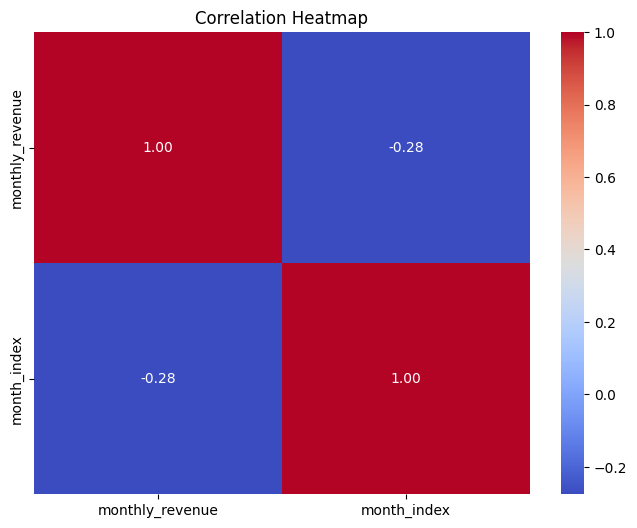

In [38]:
# numeric_only=True ထည့်မှ စာသားတွေကို ဖယ်ပြီး ကိန်းဂဏန်းတွေကိုပဲ တွက်မှာပါ
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# SQL Query (နေ့စဉ်ရောင်းအား)
query_anomaly = """
    SELECT DATE(t.trans_date) as date, 
           SUM(ti.quantity * p.price) as daily_revenue
    FROM transactions t
    JOIN transaction_items ti ON t.trans_id = ti.trans_id
    JOIN products p ON ti.product_id = p.product_id
    WHERE t.status = 'completed'
      AND t.trans_date >= DATE_SUB(CURDATE(), INTERVAL 6 MONTH)
    GROUP BY date ORDER BY date ASC
"""
df_anomaly = pd.read_sql(query_anomaly, conn)
df_anomaly['date'] = pd.to_datetime(df_anomaly['date'])

In [40]:
# ၁။ ပျမ်းမျှ (Mean) နဲ့ ကွာဟချက် (Std Dev) တွက်မယ်
mean = df_anomaly['daily_revenue'].mean()
std = df_anomaly['daily_revenue'].std()

# ၂။ Z-Score တွက်ချက်ခြင်း
# Z = (Value - Mean) / Std Dev
df_anomaly['z_score'] = (df_anomaly['daily_revenue'] - mean) / std

# ၃။ Threshold သတ်မှတ်ခြင်း (ပုံမှန်အားဖြင့် 2 ထက်ကျော်ရင် Anomaly လို့ သတ်မှတ်တယ်)
threshold = 2
df_anomaly['is_anomaly'] = df_anomaly['z_score'].abs() > threshold

# Anomaly ဖြစ်တဲ့ ရက်တွေကိုပဲ ထုတ်ကြည့်မယ်
anomalies = df_anomaly[df_anomaly['is_anomaly'] == True]
print("--- Found Anomalies ---")
print(anomalies[['date', 'daily_revenue', 'z_score']])

--- Found Anomalies ---
          date  daily_revenue   z_score
0   2025-08-12        73000.0 -3.148030
35  2025-09-16     21881500.0  2.047087
44  2025-09-25     26777100.0  3.213293
50  2025-10-01     24788500.0  2.739578
69  2025-10-20     23751900.0  2.492644
76  2025-10-27      3636200.0 -2.299222
111 2025-12-01     23212900.0  2.364246
132 2025-12-22     21886200.0  2.048206
150 2026-01-09     22380400.0  2.165932


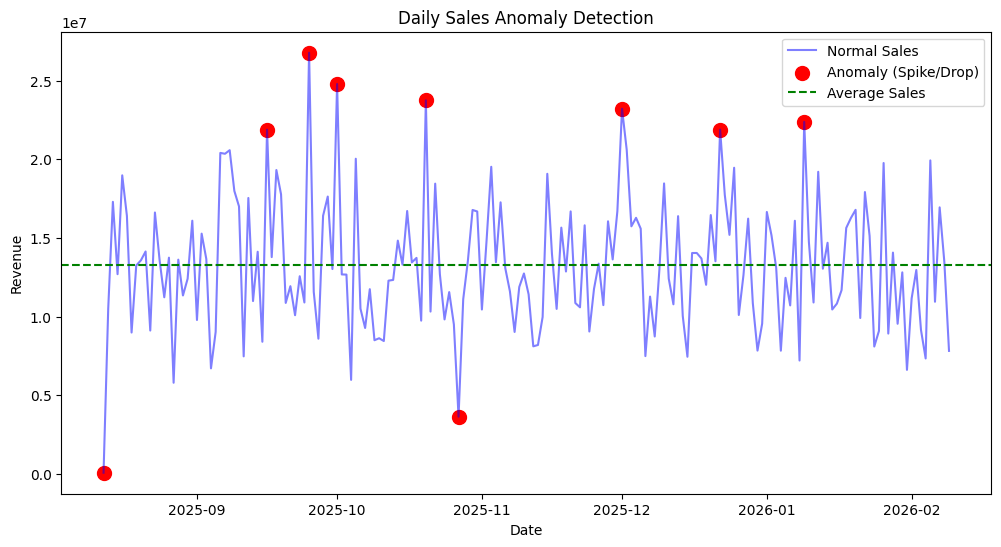

In [41]:
plt.figure(figsize=(12, 6))

# ပုံမှန် အရောင်းမျဉ်းကြောင်း
plt.plot(df_anomaly['date'], df_anomaly['daily_revenue'], color='blue', label='Normal Sales', alpha=0.5)

# Anomaly ဖြစ်တဲ့နေရာကို အနီစက်ကြီးကြီးနဲ့ပြမယ်
plt.scatter(anomalies['date'], anomalies['daily_revenue'], color='red', s=100, label='Anomaly (Spike/Drop)')

# ပျမ်းမျှမျဉ်း (Mean Line)
plt.axhline(y=mean, color='green', linestyle='--', label='Average Sales')

plt.title('Daily Sales Anomaly Detection')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.show()

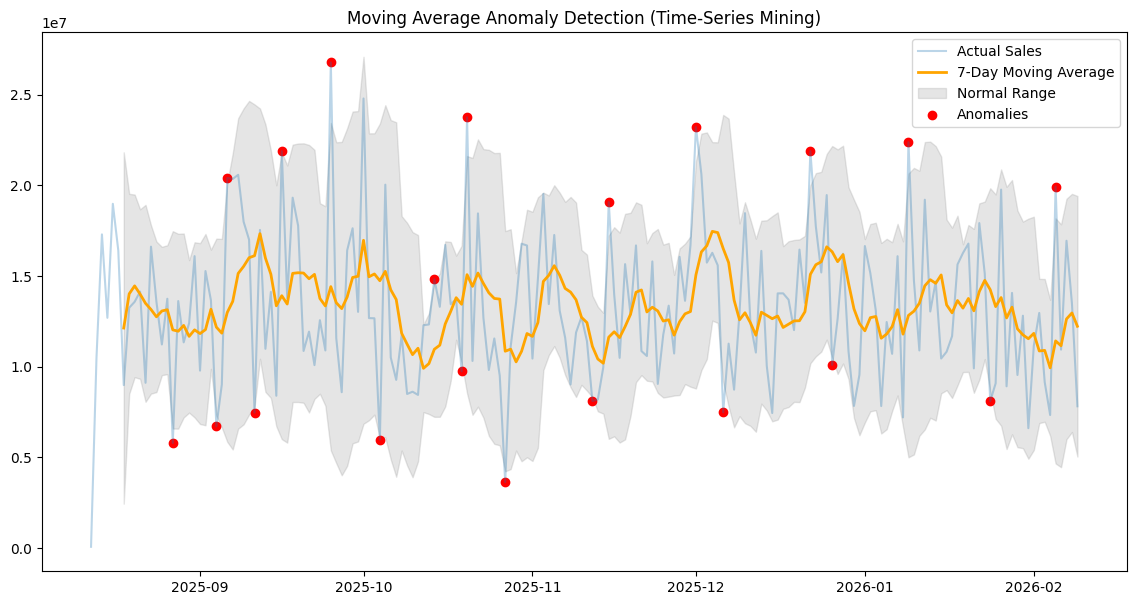

In [42]:
# ၁။ ၇ ရက်စာ Moving Average နဲ့ Standard Deviation တွက်မယ်
window = 7
df_anomaly['rolling_mean'] = df_anomaly['daily_revenue'].rolling(window=window).mean()
df_anomaly['rolling_std'] = df_anomaly['daily_revenue'].rolling(window=window).std()

# ၂။ Upper နဲ့ Lower Bound (ဘောင်) သတ်မှတ်ခြင်း
# ပျမ်းမျှရဲ့ အပေါ်/အောက် 1.5 standard deviation ကို 'ပုံမှန်' လို့ ယူဆမယ်
df_anomaly['upper_bound'] = df_anomaly['rolling_mean'] + (1.5 * df_anomaly['rolling_std'])
df_anomaly['lower_bound'] = df_anomaly['rolling_mean'] - (1.5 * df_anomaly['rolling_std'])

# ၃။ ဘောင်ကျော်တဲ့ အစက်တွေကို ရှာမယ်
df_anomaly['is_moving_anomaly'] = (df_anomaly['daily_revenue'] > df_anomaly['upper_bound']) | (df_anomaly['daily_revenue'] < df_anomaly['lower_bound'])
moving_anomalies = df_anomaly[df_anomaly['is_moving_anomaly'] == True]

# ၄။ Visualization
plt.figure(figsize=(14, 7))
plt.plot(df_anomaly['date'], df_anomaly['daily_revenue'], label='Actual Sales', alpha=0.3)
plt.plot(df_anomaly['date'], df_anomaly['rolling_mean'], label='7-Day Moving Average', color='orange', linewidth=2)

# အပေါ်ဘောင်နဲ့ အောက်ဘောင်ကို အရောင်မှိုင်းမှိုင်းလေး ခြယ်မယ် (Bollinger Bands ပုံစံ)
plt.fill_between(df_anomaly['date'], df_anomaly['lower_bound'], df_anomaly['upper_bound'], color='gray', alpha=0.2, label='Normal Range')

# Anomaly တွေကို အနီစက်ချမယ်
plt.scatter(moving_anomalies['date'], moving_anomalies['daily_revenue'], color='red', label='Anomalies')

plt.title('Moving Average Anomaly Detection (Time-Series Mining)')
plt.legend()
plt.show()

In [43]:

# Quadrant အတွက် ပစ္စည်းအလိုက် ဒေတာယူမယ်
query_quadrant = """
    SELECT p.product_name, 
           SUM(ti.quantity) as total_quantity,
           SUM(ti.quantity * p.price) as total_revenue
    FROM transactions t
    JOIN transaction_items ti ON t.trans_id = ti.trans_id
    JOIN products p ON ti.product_id = p.product_id
    WHERE t.status = 'completed'
      AND t.trans_date >= DATE_SUB(CURDATE(), INTERVAL 6 MONTH)
    GROUP BY p.product_name
"""
df_quadrant = pd.read_sql(query_quadrant, conn)


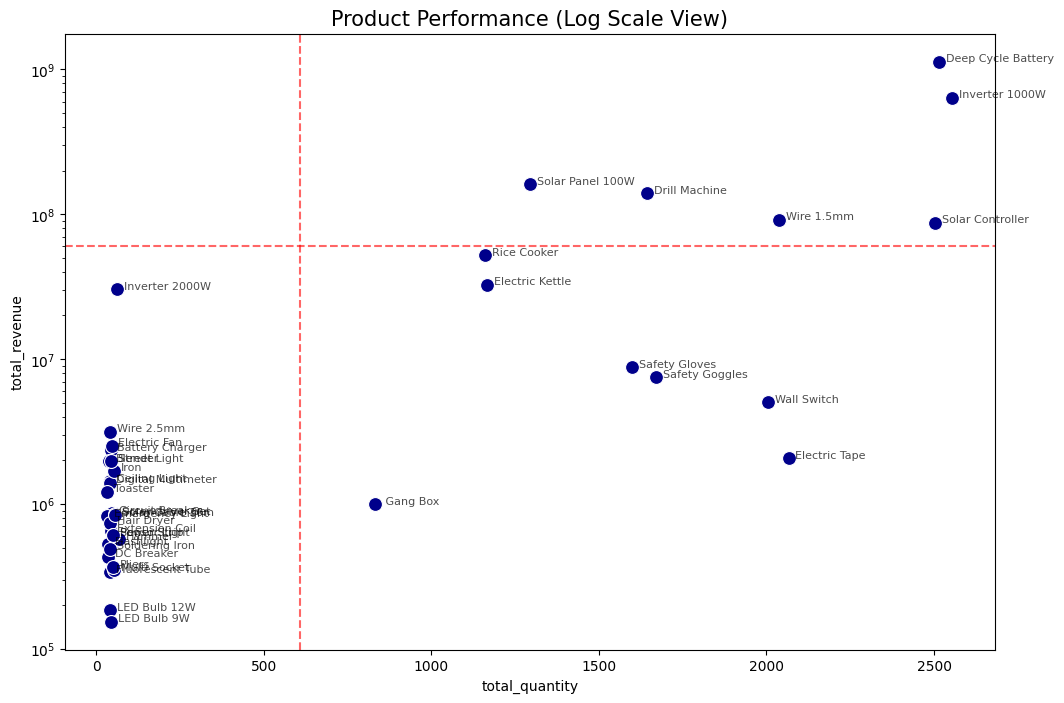

In [44]:
# ပျမ်းမျှမျဉ်းများ (သတ်မှတ်ချက်)
v_mean = df_quadrant['total_quantity'].mean()
r_mean = df_quadrant['total_revenue'].mean()

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_quadrant, x='total_quantity', y='total_revenue', s=100, color='darkblue')

# Log Scale ပြောင်းရန် (ဒါက အဓိကပဲ!)
plt.yscale('log') 

# ပျမ်းမျှမျဉ်းများကိုလည်း Log scale နှင့် ကိုက်ညီအောင် ညှိရပါမယ်
plt.axhline(r_mean, color='red', linestyle='--', alpha=0.6)
plt.axvline(v_mean, color='red', linestyle='--', alpha=0.6)

# စာသားတွေ မထပ်အောင် adjust_text library သုံးရင် ပိုကောင်းပါတယ် (မရှိရင် အောက်ကအတိုင်း ရေးပါ)
for i in range(df_quadrant.shape[0]):
    plt.text(df_quadrant.total_quantity[i] + 20, 
             df_quadrant.total_revenue[i], 
             df_quadrant.product_name[i], 
             fontsize=8, alpha=0.7)

plt.title('Product Performance (Log Scale View)', fontsize=15)
plt.show()